# Olist CLV-ML — Preprocessing

## Objective
Apply the preprocessing decisions defined in the EDA notebook to prepare 
the dataset for modeling.

**Decisions to implement:**
1. Log transform `total_ltv` (target variable)
2. Log transform `monetary` (feature)
3. Impute missing `avg_review_score` with median
4. Drop `max_review_score` and `customer_unique_id`
5. Train/test split 80/20 — GridSearchCV with cross-validation will be 
   applied on the train set during modeling, making a separate validation 
   set unnecessary.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, TargetEncoder, OneHotEncoder
import os

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

# Load from Neon and save locally
df = pd.read_sql("SELECT * FROM clean.features", engine)
df.to_csv('../data/clean/features.csv', index=False)

# Load from local CSV
df = pd.read_csv('../data/clean/features.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (93358, 10)


,customer_unique_id,days_since_first_purchase,frequency,monetary,max_review_score,avg_review_score,payment_type,payment_installments,product_category_name_english,total_ltv
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,129.90,5.0,5.0,credit_card,8.0,bed_bath_table,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,18.90,4.0,4.0,credit_card,1.0,health_beauty,18.90
2,0000f46a3911fa3c0805444483337064,586,1,69.00,3.0,3.0,credit_card,8.0,stationery,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,25.99,4.0,4.0,credit_card,4.0,telephony,25.99
4,0004aac84e0df4da2b147fca70cf8255,337,1,180.00,5.0,5.0,credit_card,6.0,telephony,180.00


## 2. Data Cleaning
### 2.1 Duplicates

In [2]:
duplicates = df.duplicated(subset='customer_unique_id').sum()
print(f"Duplicate customer_unique_id: {duplicates}")

Duplicate customer_unique_id: 0


No duplicate customers found. Each row represents a unique customer.

### 2.2 Outliers

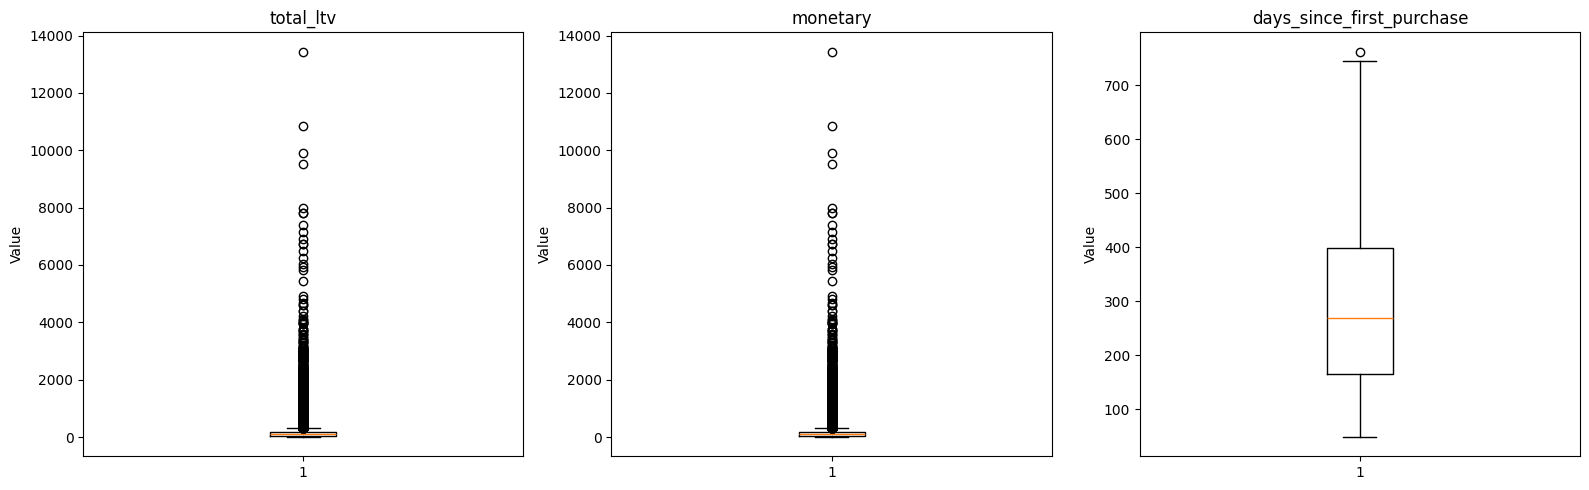

total_ltv: 7934 outliers (8.5%)
monetary: 7934 outliers (8.5%)
days_since_first_purchase: 1 outliers (0.0%)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['total_ltv', 'monetary', 'days_since_first_purchase']):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

for col in ['total_ltv', 'monetary', 'days_since_first_purchase']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)")

### Outlier Decision

- **total_ltv**: 7,934 outliers (8.5%) — high-value customers, NOT removed
- **monetary**: 7,934 outliers (8.5%) — same customers, NOT removed  
- **days_since_first_purchase**: 1 outlier (0.0%) — negligible, NOT removed

**Decision:** Outliers are not removed. In LTV modeling, high-value customers 
are the most important segment for the business. Removing them would eliminate 
exactly the customers we want to identify and predict.

**Treatment:** Log transformation applied to `total_ltv` and `monetary` 
compresses the scale and reduces the influence of extreme values without 
discarding any customer data.

## 3. Transformations
### 3.1 Log Transform

In [4]:
# Log transform target variable
df['log_ltv'] = np.log1p(df['total_ltv'])

# Log transform monetary
df['log_monetary'] = np.log1p(df['monetary'])

print("Log transforms applied:")
print(f"total_ltv range: [{df['total_ltv'].min():.2f}, {df['total_ltv'].max():.2f}]")
print(f"log_ltv range:   [{df['log_ltv'].min():.2f}, {df['log_ltv'].max():.2f}]")
print(f"\nmonetary range:     [{df['monetary'].min():.2f}, {df['monetary'].max():.2f}]")
print(f"log_monetary range: [{df['log_monetary'].min():.2f}, {df['log_monetary'].max():.2f}]")

Log transforms applied:
total_ltv range: [0.85, 13440.00]
log_ltv range:   [0.62, 9.51]

monetary range:     [0.85, 13440.00]
log_monetary range: [0.62, 9.51]


### 3.2 Imputation

In [5]:
median_review = df['avg_review_score'].median()
df['avg_review_score'] = df['avg_review_score'].fillna(median_review)

print(f"avg_review_score imputed with median: {median_review}")
print(f"Missing values remaining: {df['avg_review_score'].isnull().sum()}")

avg_review_score imputed with median: 5.0
Missing values remaining: 0


### 3.3 Drop Columns

In [6]:
df = df.drop(columns=['customer_unique_id', 'max_review_score', 'total_ltv', 'monetary'])

print(f"Shape after dropping columns: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

Shape after dropping columns: (93358, 8)
Remaining columns: ['days_since_first_purchase', 'frequency', 'avg_review_score', 'payment_type', 'payment_installments', 'product_category_name_english', 'log_ltv', 'log_monetary']


### 3.4 Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

features_to_scale = ['days_since_first_purchase', 'frequency', 'avg_review_score', 'log_monetary', 'payment_installments']

scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Scaling applied:")
df[features_to_scale].describe().round(3)

Scaling applied:


,days_since_first_purchase,frequency,avg_review_score,log_monetary,payment_installments
count,93358.000,93358.000,93358.000,93358.000,93357.000
mean,-0.000,-0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-1.568,-0.160,-2.474,-4.160,-1.079
25%,-0.811,-0.160,-0.125,-0.643,-0.709
50%,-0.125,-0.160,0.657,-0.003,-0.339
75%,0.718,-0.160,0.657,0.607,0.401
max,3.089,66.795,0.657,5.330,7.802


### Scaling Results

StandardScaler applied to all features (excluding target variable `log_ltv`).
All features now have mean=0 and std=1.

Note: `log_ltv` (target variable) is not scaled — predictions will be in 
log scale and converted back to BRL with `np.expm1()` after modeling.

## 4. Feature Selection

In [8]:
print("Final features for modeling:")
print(f"\nFeatures (X): {[col for col in df.columns if col != 'log_ltv']}")
print(f"Target (y): log_ltv")
print(f"\nFinal dataset shape: {df.shape}")
df.head()

Final features for modeling:

Features (X): ['days_since_first_purchase', 'frequency', 'avg_review_score', 'payment_type', 'payment_installments', 'product_category_name_english', 'log_monetary']
Target (y): log_ltv

Final dataset shape: (93358, 8)


,days_since_first_purchase,frequency,avg_review_score,payment_type,payment_installments,product_category_name_english,log_ltv,log_monetary
0,-0.843385,-0.159829,0.657414,credit_card,1.881352,bed_bath_table,4.874434,0.386351
1,-0.823791,-0.159829,-0.125472,credit_card,-0.708908,health_beauty,2.990720,-1.624407
2,1.939074,-0.159829,-0.908358,credit_card,1.881352,stationery,4.248495,-0.281803
3,0.528249,-0.159829,-0.125472,credit_card,0.401204,telephony,3.295466,-1.299107
4,0.312707,-0.159829,0.657414,credit_card,1.141278,telephony,5.198497,0.732270


## 5. Train/Test Split

In [9]:
X = df.drop(columns=['log_ltv'])
y = df['log_ltv']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"\nTrain size: {len(X_train)/len(df)*100:.0f}%")
print(f"Test size:  {len(X_test)/len(df)*100:.0f}%")

X_train: (74686, 7)
X_test:  (18672, 7)
y_train: (74686,)
y_test:  (18672,)

Train size: 80%
Test size:  20%


## 6. Encoding

Encoding is applied **after** the train/test split to prevent data leakage.
Target Encoding uses only training data statistics and is then applied to the test set.

### 6.1 Target Encoding — product_category_name_english

In [10]:
te = TargetEncoder(random_state=42)

X_train['product_category_encoded'] = te.fit_transform(
    X_train[['product_category_name_english']], y_train
)
X_test['product_category_encoded'] = te.transform(
    X_test[['product_category_name_english']]
)

X_train = X_train.drop(columns=['product_category_name_english'])
X_test = X_test.drop(columns=['product_category_name_english'])

print("Target Encoding applied")
print(f"X_train shape: {X_train.shape}")
print(f"Sample encoded values:\n{X_train['product_category_encoded'].describe().round(2)}")

Target Encoding applied
X_train shape: (74686, 7)
Sample encoded values:
count    74686.00
mean         4.51
std          0.33
min          3.13
25%          4.50
50%          4.53
75%          4.55
max          7.06
Name: product_category_encoded, dtype: float64


### 6.2 One-Hot Encoding — payment_type

In [11]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

payment_train = ohe.fit_transform(X_train[['payment_type']])
payment_test = ohe.transform(X_test[['payment_type']])

payment_cols = ohe.get_feature_names_out(['payment_type'])

X_train = X_train.drop(columns=['payment_type'])
X_test = X_test.drop(columns=['payment_type'])

X_train = pd.concat([X_train, pd.DataFrame(payment_train, columns=payment_cols, index=X_train.index)], axis=1)
X_test = pd.concat([X_test, pd.DataFrame(payment_test, columns=payment_cols, index=X_test.index)], axis=1)

# Drop nan column if exists
if 'payment_type_nan' in X_train.columns:
    X_train = X_train.drop(columns=['payment_type_nan'])
    X_test = X_test.drop(columns=['payment_type_nan'])

print("One-Hot Encoding applied")
print(f"X_train shape: {X_train.shape}")
print(f"New columns: {[c for c in X_train.columns if 'payment' in c]}")

One-Hot Encoding applied
X_train shape: (74686, 10)
New columns: ['payment_installments', 'payment_type_boleto', 'payment_type_credit_card', 'payment_type_debit_card', 'payment_type_voucher']


## 7. Summary

| Step | Action | Justification |
|---|---|---|
| Duplicates | None found | Each row is a unique customer |
| Outliers | Kept, log transform applied | High-value customers are business-critical |
| Log transform total_ltv | Applied | Strong right skew |
| Log transform monetary | Applied | Same skew pattern |
| Imputation avg_review_score | Median (5.0) | 0.65% missing, robust to outliers |
| Drop columns | customer_unique_id, max_review_score, total_ltv, monetary | ID not a feature, redundant or replaced by log version |
| Scaling | StandardScaler on numerical features | Required for Linear Regression |
| Train/test split | 80/20, random_state=42 | Standard split, reproducible |
| Target Encoding | product_category_name_english | 71 categories, captures LTV signal per category, applied after split to prevent leakage |
| One-Hot Encoding | payment_type | 4 categories, low cardinality, applied after split |

**Dataset ready for modeling:**
- Features (X): days_since_first_purchase, frequency, avg_review_score, log_monetary, payment_installments, payment_type_boleto, payment_type_credit_card, payment_type_debit_card, payment_type_voucher, product_category_encoded
- Target (y): log_ltv
- Train: 74,686 customers
- Test: 18,672 customers